# 02 — Model Training: All Labels × All Models × All Metals

Trains **5 models** on **6 label variants** for **4 metals** = 120 experiments.

| Models | Label Variants | Metals |
|--------|----------------|--------|
| LASSO (L1 logistic) | GSADF | Cobalt |
| Random Forest | LPPLS 0.30 / 0.20 / 0.10 / 0.05 | Copper |
| XGBoost | LPPLS Period-based | Lithium |
| LightGBM | | Nickel |
| CatBoost | | |

### Approach
- **Features**: lagged log-returns, rolling volatility, lagged price levels, peer bubble dummies — ALL lagged by 1 day (no look-ahead)
- **CV**: 5-fold expanding-window `TimeSeriesSplit` — scaler fitted on train fold only
- **No SMOTE** — oversampling causes single-cluster detection
- **Metrics**: AUC, F1 (threshold-optimized), Sensitivity, Precision, Episodes detected

### Output
- `outputs/all_results.csv` — full results table
- `outputs/best_per_metal.csv` — best model per metal per label variant


In [12]:
import pandas as pd, numpy as np, os, warnings, time
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

os.makedirs('../outputs', exist_ok=True)

# ── Load all_labels.csv ───────────────────────────────────────────────────
DATA_PATH = '../outputs/all_labels.csv'
assert os.path.exists(DATA_PATH), f'{DATA_PATH} not found — run 01_data_preparation first'
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])

METALS = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
LABEL_VARIANTS = ['gsadf', 'lppls_0.30', 'lppls_0.20', 'lppls_0.10', 'lppls_0.05', 'lppls_period']

print(f'Data: {len(df)} rows, {len(df.columns)} columns')
print(f'Metals: {list(METALS.keys())}')
print(f'Label variants: {LABEL_VARIANTS}')


Data: 2152 rows, 41 columns
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
Label variants: ['gsadf', 'lppls_0.30', 'lppls_0.20', 'lppls_0.10', 'lppls_0.05', 'lppls_period']


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════════════════

def prepare_features(target_metal, label_variant, df_master):
    """Create lagged feature matrix. No look-ahead."""
    target_col = f'{target_metal}_{label_variant}'
    price_cols = ['CODALY', 'CUDALY', 'LIDALY', 'NIDALY']
    macro_cols = [c for c in df_master.columns 
                  if c not in ['Date'] + price_cols
                  and not any(c.startswith(m + '_') for m in 
                              ['Cobalt', 'Copper', 'Lithium', 'Nickel'])]
    num_cols = price_cols + macro_cols
    
    # Peer bubble dummies (same variant, other metals)
    peer_cols = [f'{m}_{label_variant}' for m in 
                 ['Cobalt', 'Copper', 'Lithium', 'Nickel'] if m != target_metal]
    peer_cols = [c for c in peer_cols if c in df_master.columns]
    
    out = pd.DataFrame({'Date': df_master['Date']})
    
    # Log returns & rolling vol (lagged)
    for col in num_cols:
        safe = df_master[col].clip(lower=0.001)
        lr = np.log(safe).diff()
        out[col + '_Ret_L1']   = lr.shift(1)
        out[col + '_Vol10_L1'] = lr.rolling(10).std().shift(1)
    
    # Lagged price levels
    for col in num_cols:
        out[col + '_Level_L1'] = df_master[col].shift(1)
    
    # Peer dummies (lagged)
    for col in peer_cols:
        out[col + '_L1'] = df_master[col].shift(1).fillna(0)
    
    out['Target'] = df_master[target_col].astype(int)
    return out.dropna().reset_index(drop=True)


def find_f1_threshold(y_true, y_prob):
    """Find threshold that maximizes F1."""
    pre, rec, thr = precision_recall_curve(y_true, y_prob)
    with np.errstate(invalid='ignore'):
        f1s = np.where((pre[:-1]+rec[:-1])>0,
                       2*pre[:-1]*rec[:-1]/(pre[:-1]+rec[:-1]), 0.0)
    i = int(np.argmax(f1s))
    return float(thr[i]), float(f1s[i])


def label_episodes(y):
    """Return array with episode id (1-based) for each positive day."""
    eps = np.zeros(len(y), dtype=int)
    eid = 0; in_b = False
    for i in range(len(y)):
        if y[i] == 1 and not in_b:
            eid += 1; in_b = True
        elif y[i] == 0:
            in_b = False
        if y[i] == 1:
            eps[i] = eid
    return eps


print('Helpers ready.')

Helpers ready.


## 1. Run All Experiments

In [14]:
MODELS = {
    'LASSO': lambda: LogisticRegression(
        penalty='l1', solver='saga', C=0.1, max_iter=10000, random_state=42),
    'RF': lambda: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        max_features='sqrt', random_state=42),
    'XGBoost': lambda: xgb.XGBClassifier(
        max_depth=3, learning_rate=0.05, n_estimators=300,
        min_child_weight=2, reg_alpha=0.5, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='auc', verbosity=0, random_state=42),
    'LightGBM': lambda: lgb.LGBMClassifier(
        max_depth=3, learning_rate=0.05, n_estimators=300,
        min_child_samples=5, reg_alpha=0.5, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        verbose=-1, random_state=42),
    'CatBoost': lambda: CatBoostClassifier(
        depth=3, learning_rate=0.05, iterations=300,
        l2_leaf_reg=3.0, subsample=0.8,
        verbose=0, random_state=42),
}

# Models that need StandardScaler (linear only)
NEEDS_SCALE = {'LASSO'}

N_SPLITS = 5
results = []
t0 = time.time()
total_exp = len(METALS) * len(LABEL_VARIANTS) * len(MODELS)
exp_i = 0

for metal in METALS:
    for variant in LABEL_VARIANTS:
        label_col = f'{metal}_{variant}'
        if label_col not in df.columns:
            continue

        # Skip if too few positives
        n_pos_total = int(df[label_col].sum())
        if n_pos_total < 10:
            for mname in MODELS:
                exp_i += 1
                results.append(dict(
                    Metal=metal, Variant=variant, Model=mname,
                    BubDays=n_pos_total, AUC=np.nan, F1=np.nan,
                    Sens=np.nan, Prec=np.nan, Spec=np.nan,
                    Detected='0/0', EpDet='0/0', Note='too_few_pos'))
            continue

        # Prepare features (all lagged — no look-ahead)
        df_ml = prepare_features(metal, variant, df)
        feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
        X = df_ml[feats].values
        y = df_ml['Target'].values
        dates_arr = df_ml['Date']

        for mname, model_fn in MODELS.items():
            exp_i += 1
            tscv = TimeSeriesSplit(n_splits=N_SPLITS)
            all_p, all_t = [], []

            for train_idx, test_idx in tscv.split(X):
                Xtr, Xte = X[train_idx], X[test_idx]
                ytr, yte = y[train_idx], y[test_idx]

                if ytr.sum() < 5 or yte.sum() == 0:
                    continue

                # Scale fitted on train only — no spillover
                if mname in NEEDS_SCALE:
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(Xtr)
                    Xte = sc.transform(Xte)

                m = model_fn()
                m.fit(Xtr, ytr)
                p = m.predict_proba(Xte)[:, 1]
                all_p.append(p)
                all_t.append(yte)

            if not all_p:
                results.append(dict(
                    Metal=metal, Variant=variant, Model=mname,
                    BubDays=n_pos_total, AUC=np.nan, F1=np.nan,
                    Sens=np.nan, Prec=np.nan, Spec=np.nan,
                    Detected='0/0', EpDet='0/0', Note='no_valid_fold'))
                continue

            yt = np.concatenate(all_t)
            yp = np.concatenate(all_p)

            auc = roc_auc_score(yt, yp)
            opt_t, opt_f1 = find_f1_threshold(yt, yp)
            ypred = (yp >= opt_t).astype(int)
            tn, fp, fn, tp = confusion_matrix(yt, ypred, labels=[0, 1]).ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0

            # Episode detection
            eps = label_episodes(yt)
            ep_total = set(eps[eps > 0])
            ep_det = {eid for eid in ep_total if ypred[eps == eid].sum() > 0}

            results.append(dict(
                Metal=metal, Variant=variant, Model=mname,
                BubDays=n_pos_total,
                AUC=round(auc, 3), F1=round(opt_f1, 3),
                Sens=round(sens, 3), Prec=round(prec, 3), Spec=round(spec, 3),
                Detected=f'{tp}/{tp+fn}',
                EpDet=f'{len(ep_det)}/{len(ep_total)}',
                Note=''))

            if exp_i % 15 == 0 or exp_i == total_exp:
                elapsed = time.time() - t0
                print(f'  [{exp_i:3d}/{total_exp}]  {elapsed:.0f}s  '
                      f'{metal:8s} {variant:14s} {mname:8s}  '
                      f'AUC={auc:.3f} F1={opt_f1:.3f}')

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/all_results.csv', index=False)
print(f'\nDone! {len(df_results)} experiments in {time.time()-t0:.0f}s')
print(f'Saved → outputs/all_results.csv')


  [ 15/120]  24s  Cobalt   lppls_0.20     CatBoost  AUC=0.925 F1=0.222
  [ 30/120]  47s  Cobalt   lppls_period   CatBoost  AUC=0.653 F1=0.211
  [ 45/120]  66s  Copper   lppls_0.20     CatBoost  AUC=0.760 F1=0.145
  [ 60/120]  96s  Copper   lppls_period   CatBoost  AUC=0.575 F1=0.267
  [ 75/120]  111s  Lithium  lppls_0.20     CatBoost  AUC=0.178 F1=0.052
  [ 90/120]  129s  Lithium  lppls_period   CatBoost  AUC=0.434 F1=0.137
  [105/120]  138s  Nickel   lppls_0.20     CatBoost  AUC=0.450 F1=0.109
  [120/120]  154s  Nickel   lppls_period   CatBoost  AUC=0.352 F1=0.345

Done! 120 experiments in 154s
Saved → outputs/all_results.csv


## 2. Results Overview

In [15]:
import matplotlib.pyplot as plt

df_r = df_results[df_results.Note != 'too_few_pos'].copy()
df_r = df_r[df_r.AUC.notna()].copy()

# ── Best model per metal per variant ──────────────────────────────────────
best = df_r.loc[df_r.groupby(['Metal', 'Variant'])['F1'].idxmax()].copy()
best = best.sort_values(['Metal', 'F1'], ascending=[True, False])
best.to_csv('../outputs/best_per_metal.csv', index=False)

print('Best model per metal per label variant (by F1):')
print('=' * 100)
print(f'{"Metal":>8s}  {"Variant":>14s}  {"Model":>8s}  '
      f'{"BubDays":>7s}  {"AUC":>5s}  {"F1":>5s}  {"Sens":>5s}  '
      f'{"Prec":>5s}  {"Detected":>8s}  {"EpDet":>7s}')
print('-' * 100)
for _, r in best.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>8s}  '
          f'{r.BubDays:>7d}  {r.AUC:>5.3f}  {r.F1:>5.3f}  {r.Sens:>5.3f}  '
          f'{r.Prec:>5.3f}  {r.Detected:>8s}  {r.EpDet:>7s}')

print(f'\nSaved → outputs/best_per_metal.csv')

Best model per metal per label variant (by F1):
   Metal         Variant     Model  BubDays    AUC     F1   Sens   Prec  Detected    EpDet
----------------------------------------------------------------------------------------------------
  Cobalt      lppls_0.05     LASSO       64  0.909  0.515  0.593  0.455     35/59      5/7
  Cobalt      lppls_0.20     LASSO       20  0.981  0.500  1.000  0.333       5/5      1/1
  Cobalt      lppls_0.30     LASSO       14  0.981  0.500  1.000  0.333       5/5      1/1
  Cobalt      lppls_0.10     LASSO       53  0.895  0.415  0.562  0.329     27/48      6/6
  Cobalt           gsadf        RF      230  0.641  0.320  0.446  0.249    99/222     9/14
  Cobalt    lppls_period     LASSO       71  0.826  0.317  0.857  0.194     54/63      4/4
  Copper           gsadf  LightGBM       39  0.961  0.571  0.667  0.500       6/9      2/2
  Copper      lppls_0.10  CatBoost      115  0.610  0.325  0.248  0.473    26/105     6/22
  Copper      lppls_0.05        

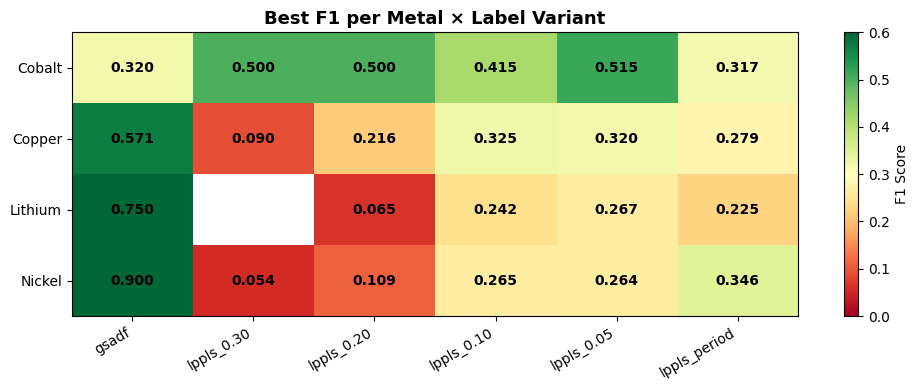

In [16]:
# ── Heatmap: F1 by (Metal×Variant) for best model ────────────────────────
pivot = best.pivot_table(index='Metal', columns='Variant', values='F1')
pivot = pivot.reindex(columns=['gsadf','lppls_0.30','lppls_0.20','lppls_0.10','lppls_0.05','lppls_period'])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Best F1 per Metal × Label Variant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_f1_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

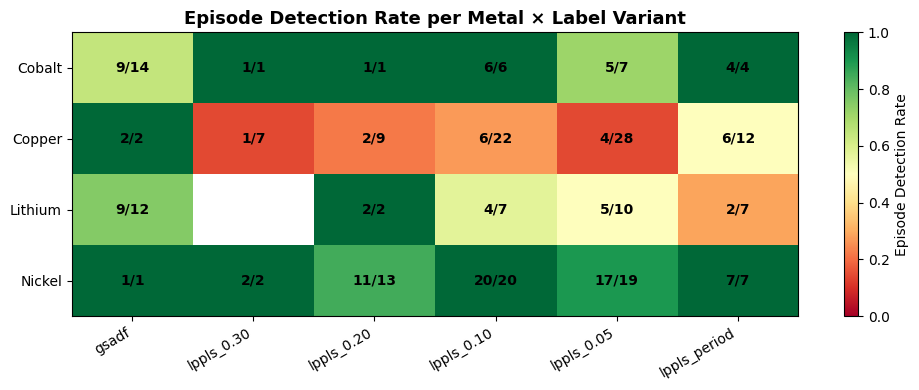


All results saved. Proceed to 03_master_summary.ipynb for analysis.


In [17]:
# ── Heatmap: Episode Detection Rate ──────────────────────────────────────
def ep_rate(s):
    """Parse '5/7' -> 5/7 = 0.714"""
    parts = s.split('/')
    if len(parts) == 2 and int(parts[1]) > 0:
        return int(parts[0]) / int(parts[1])
    return np.nan

best['EpRate'] = best['EpDet'].apply(ep_rate)

pivot_ep = best.pivot_table(index='Metal', columns='Variant', values='EpRate')
pivot_ep = pivot_ep.reindex(columns=['gsadf','lppls_0.30','lppls_0.20','lppls_0.10','lppls_0.05','lppls_period'])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_ep.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)
ax.set_xticks(range(len(pivot_ep.columns)))
ax.set_xticklabels(pivot_ep.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot_ep.index)))
ax.set_yticklabels(pivot_ep.index, fontsize=10)

for i in range(len(pivot_ep.index)):
    for j in range(len(pivot_ep.columns)):
        val = pivot_ep.iloc[i, j]
        if not np.isnan(val):
            ep_str = best[(best.Metal == pivot_ep.index[i]) & 
                          (best.Variant == pivot_ep.columns[j])]['EpDet'].values
            txt = ep_str[0] if len(ep_str) > 0 else f'{val:.0%}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='Episode Detection Rate')
ax.set_title('Episode Detection Rate per Metal × Label Variant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_episode_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nAll results saved. Proceed to 03_master_summary.ipynb for analysis.')